# Multi-Layer Perceptron - Supervised Multiclass Task

This pipeline includes data preprocessing, specific for this model, followed by the training and the evaluation of the classifier. The options in terms of data preprocessing and hyperparameters are the same as in the previous the Binary Classification task.

DONATION_TYPE                 0
MONTHS_SINCE_ORIGIN           0
IN_HOUSE                      0
MOR_HIT_RATE                  0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PCT_OWNER_OCCUPIED            0
PER_CAPITA_INCOME             0
PCT_ATTRIBUTE1                0
PCT_ATTRIBUTE2                0
PCT_ATTRIBUTE3                0
PCT_ATTRIBUTE4                0
PEP_STAR                      0
RECENT_STAR_STATUS            0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
LIFETIME_GIFT_AMOUNT          0
LIFETIME_GIFT_COUNT           0
LIFETIME_AVG_GIFT_AMT         0
LIFETIME_GIFT_RANGE           0
LIFETIME_MAX_GIFT_AMT         0
LIFETIME_MIN_GIFT_AMT         0
LAST_GIFT_AMT                 0
CARD_PROM_12                  0
NUMBER_P

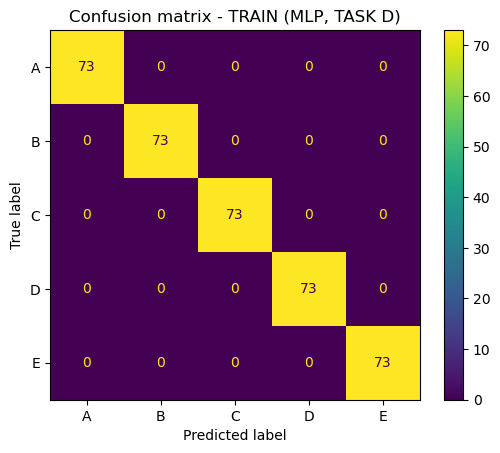

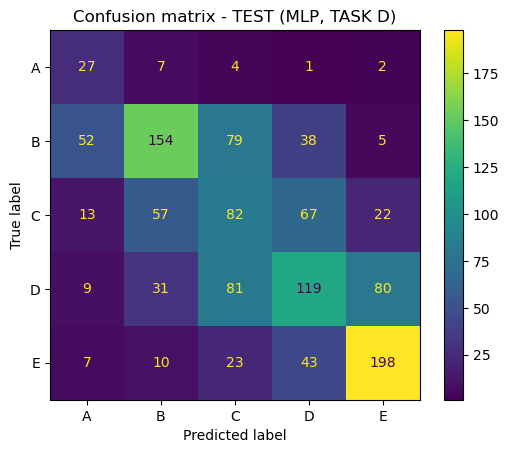

TRAIN classification report (TASK D):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        73
           B       1.00      1.00      1.00        73
           C       1.00      1.00      1.00        73
           D       1.00      1.00      1.00        73
           E       1.00      1.00      1.00        73

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

TEST classification report (TASK D):
              precision    recall  f1-score   support

           A       0.25      0.66      0.36        41
           B       0.59      0.47      0.52       328
           C       0.30      0.34      0.32       241
           D       0.44      0.37      0.40       320
           E       0.64      0.70      0.67       281

    accuracy                           0.48      1211
   macro avg       0.45      0.51      0.46      1211
we

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

#for more information: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
hidden_layer_sizes = (200,200,100,100,200)  #(100,)
activation = 'relu' # 'relu'
solver = 'adam'  #'adam'
alpha = 0.0001    # 0.0001
early_stopping = False
max_iter = 200 #200

STANDARDIZE = True
BALANCE = True

df_donors = pd.read_csv('Donors_dataset.csv')

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Use only rows with non-null TARGET_D
df_D = df_donors[df_donors["TARGET_D"].notnull()].copy()
df_D["DONATION_TYPE"] = df_D["TARGET_D"].apply(donation_type)

num_features = ["MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
]

# Keep only DONATION_TYPE + selected predictors
df_D = df_D[["DONATION_TYPE"] + num_features + cat_features].copy()

# check missing values in these columns
print(df_D.isna().sum()) # df_D.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# Handle missing numericals: median + "_unknown" flag
for col in num_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    median_val = df_D[col].median()
    df_D[col] = df_D[col].fillna(median_val)

# Handle missing categoricals: "Unknown" category
for col in cat_features:
    df_D[col] = df_D[col].fillna("Unknown")

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_D_encoded = pd.get_dummies(df_D, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TASK D model
X_D = df_D_encoded.drop("DONATION_TYPE", axis=1)
y_D = df_D_encoded["DONATION_TYPE"]

X_D.head()

# Train/test split
X_D_train, X_D_test, y_D_train, y_D_test = train_test_split(
    X_D, y_D, random_state=42
)

if BALANCE:
    train_df_D = pd.concat([X_D_train, y_D_train], axis=1)

    # Undersample all classes to the size of the smallest class
    class_counts = train_df_D["DONATION_TYPE"].value_counts()
    min_count = class_counts.min()

    balanced_list = []
    for cls in class_counts.index:
        cls_df = train_df_D[train_df_D["DONATION_TYPE"] == cls]
        cls_df_bal = resample(
            cls_df,
            replace=False,
            n_samples=min_count,
            random_state=42
        )
        balanced_list.append(cls_df_bal)

    train_balanced_D = pd.concat(balanced_list)

    X_D_train_bal = train_balanced_D.drop("DONATION_TYPE", axis=1)
    y_D_train_bal = train_balanced_D["DONATION_TYPE"]
else:
    X_D_train_bal = X_D_train
    y_D_train_bal = y_D_train

# Standardize features (as in TP12)
if STANDARDIZE:
    sc = StandardScaler()
    sc.fit(X_D_train_bal)
    X_D_train_std = sc.transform(X_D_train_bal)
    X_D_test_std  = sc.transform(X_D_test)
else:
    X_D_train_std = X_D_train_bal
    X_D_test_std  = X_D_test

# Neural network (MLPClassifier), similar style to TP12
mlp_D = MLPClassifier(max_iter=max_iter, random_state=20,
                      alpha=alpha,
                      early_stopping=early_stopping,
                      hidden_layer_sizes=hidden_layer_sizes,
                      solver=solver
                      )

mlp_D.fit(X_D_train_std, y_D_train_bal)

print("Train set accuracy =", mlp_D.score(X_D_train_std, y_D_train_bal))
print("Test set accuracy  =", mlp_D.score(X_D_test_std, y_D_test))

###### Confusion matrices
y_D_train_pred = mlp_D.predict(X_D_train_std)
y_D_test_pred  = mlp_D.predict(X_D_test_std)

cm_train_D = confusion_matrix(y_D_train_bal, y_D_train_pred)
disp_train_D = ConfusionMatrixDisplay(confusion_matrix=cm_train_D,
                                      display_labels=mlp_D.classes_)
disp_train_D.plot()
plt.title("Confusion matrix - TRAIN (MLP, TASK D)")
plt.show()

cm_test_D = confusion_matrix(y_D_test, y_D_test_pred)
disp_test_D = ConfusionMatrixDisplay(confusion_matrix=cm_test_D,
                                     display_labels=mlp_D.classes_)
disp_test_D.plot()
plt.title("Confusion matrix - TEST (MLP, TASK D)")
plt.show()

# Classification report
print("TRAIN classification report (TASK D):")
print(classification_report(y_D_train_bal, y_D_train_pred))

print("TEST classification report (TASK D):")
print(classification_report(y_D_test, y_D_test_pred))

# Get probabilities for all classes (A, B, C, D, E)
scores_test_D = mlp_D.predict_proba(X_D_test_std)

# Define the labels based on the trained model
all_classes = mlp_D.classes_

# Calculate Macro AUC (One-vs-Rest)
auc_test_D = roc_auc_score(
    y_D_test,
    scores_test_D,
    labels=all_classes,
    multi_class="ovr",
    average="macro"
)

print(f"TEST macro AUC (TASK D) = {auc_test_D:.4f}")
